# Writer-Independent Sinhala Handwritten Text Line Recognition (Final Colab, tuned v4)
This notebook is a **clean final training pipeline** for My research project:

**A Writer-Independent Deep Learning Framework for Recognition of Sinhala Handwritten Text Lines from Lower Secondary Students**

It is designed to help you train **one final model** on your **full segmented dataset**, using:

- **Writer-independent split** (grouped by writer/page ID)
- **DenseNet121-CRNN** as the final model
- **CTC loss**
- **CER and WER**
- **best-checkpoint saving**
- **sample prediction visualization**

> Important: this notebook assumes that all lines from the same student/page share a common filename prefix, such as `G9_0016_L01.png`, where `G9_0016` can be used as the writer/page ID.


## 1. Runtime and package setup
Run this cell first in Colab. Then choose **GPU runtime** before training.

In [1]:
import os
import re
import gc
import json
import math
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models


print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core >/dev/null

import os
import textwrap
from matplotlib import font_manager as fm

SINHALA_FONT_CANDIDATES = [
    "/usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf",
    "/usr/share/fonts/truetype/noto/NotoSerifSinhala-Regular.ttf",
]
SINHALA_FONT_PATH = next((p for p in SINHALA_FONT_CANDIDATES if os.path.exists(p)), None)
assert SINHALA_FONT_PATH is not None, "Could not find a Sinhala font in Colab."

fm.fontManager.addfont(SINHALA_FONT_PATH)
SINHALA_FONT = fm.FontProperties(fname=SINHALA_FONT_PATH)
SINHALA_FONT_NAME = SINHALA_FONT.get_name()

# Keep a Latin-friendly default font globally and use the Sinhala font only for Sinhala strings.
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

def _wrap_display_text(text, width=80):
    text = str(text)
    return textwrap.fill(
        text,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )

def draw_text_block(ax, path_text=None, gt_text=None, pred_text=None, sample_text=None, match_text=None):
    """Draw metadata in a dedicated text-only axis so it never overlaps the image."""
    ax.axis("off")
    ax.set_facecolor("white")

    entries = []
    if path_text is not None:
        entries.append(("Path", _wrap_display_text(path_text, width=70), "latin"))
    if sample_text is not None:
        entries.append(("Text", _wrap_display_text(sample_text, width=58), "sinhala"))
    if gt_text is not None:
        entries.append(("GT (label)", _wrap_display_text(gt_text, width=58), "sinhala"))
    if pred_text is not None:
        entries.append(("Pred (model)", _wrap_display_text(pred_text, width=58), "sinhala"))
    if match_text is not None:
        entries.append(("Match", _wrap_display_text(match_text, width=58), "latin"))

    y = 0.97
    label_x = 0.01
    value_x = 0.13

    for label, value, kind in entries:
        ax.text(
            label_x, y, f"{label}:",
            transform=ax.transAxes,
            fontsize=11,
            va="top",
            ha="left",
            fontfamily="DejaVu Sans",
        )
        text_kwargs = dict(
            transform=ax.transAxes,
            fontsize=12,
            va="top",
            ha="left",
        )
        if kind == "sinhala":
            text_kwargs["fontproperties"] = SINHALA_FONT
        else:
            text_kwargs["fontfamily"] = "DejaVu Sans"

        ax.text(value_x, y, value, **text_kwargs)

        line_count = value.count("\n") + 1
        y -= 0.23 * line_count + 0.10

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

print("Using Sinhala font:", SINHALA_FONT_NAME)
print("Matplotlib default font:", plt.rcParams["font.family"])



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Using Sinhala font: Noto Sans Sinhala
Matplotlib default font: ['DejaVu Sans']


## 2. Config
Set your Google Drive dataset source here.

- `DATA_SOURCE_PATH` can point to either:
  - a `.zip` file in Google Drive, or
  - an already extracted dataset folder
- the notebook will mount Drive, extract if needed, and auto-detect the labels CSV and image root


In [3]:

# =========================
# CONFIG
# =========================
# Put your dataset source here.
# This can be either:
#   1) a zip file in Drive, e.g. /content/drive/MyDrive/DATASET_FOR_RESEARCH/dataset.zip
#   2) an extracted folder, e.g. /content/drive/MyDrive/DATASET_FOR_RESEARCH/dataset

DATA_SOURCE_PATH = "/content/drive/MyDrive/DATASET_FOR_RESEARCH/dataset.zip"

# Where to extract the zip inside Colab (only used when DATA_SOURCE_PATH ends with .zip)
EXTRACT_DIR = "/content/final_dataset"

# Optional: if you already know the labels CSV path, put it here.
# Otherwise leave as None and the notebook will auto-detect it.
LABELS_CSV_HINT = None

# Column name hints
IMG_COL_CANDIDATES = ["image", "img", "image_path", "path", "filepath", "file", "filename"]
TEXT_COL_CANDIDATES = ["text", "transcription", "label", "sentence", "gt", "target"]

# Safe tuning switches
USE_TRAIN_AUGMENT = True
NORMALIZE_TO_MINUS1_1 = True
STRICT_REPRODUCIBILITY = True   # keep results much more stable across reruns

# Final evaluation decoder
FINAL_DECODER = "beam"   # "greedy" or "beam"
BEAM_WIDTH = 10


IMG_HEIGHT = 64
IMG_WIDTH = 640
BATCH_SIZE = 12
NUM_WORKERS = 2

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

SEED = 42
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8

USE_PRETRAINED = True
USE_AMP = torch.cuda.is_available() and (not STRICT_REPRODUCIBILITY)

OUTPUT_DIR = Path("/content/outputs_writer_independent_densenet121")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8, "Ratios must sum to 1"
print("Output dir:", OUTPUT_DIR)


Output dir: /content/outputs_writer_independent_densenet121


## 3. Mount Drive, extract dataset if needed, and auto-detect paths
This cell makes the notebook work directly with a Google Drive `.zip` file like your `dataset.zip`.


In [4]:

from pathlib import Path
import zipfile

def maybe_mount_drive(path_str: str):
    if path_str.startswith("/content/drive/"):
        try:
            from google.colab import drive
            if not Path("/content/drive").exists():
                drive.mount("/content/drive")
            else:
                # Mount again safely in case it is not yet mounted
                drive.mount("/content/drive", force_remount=False)
        except Exception as e:
            print("Drive mount skipped or failed:", e)

def choose_existing_root(image_rel_paths, candidate_roots):
    best_root, best_score = None, -1
    sample = [str(p) for p in image_rel_paths[: min(50, len(image_rel_paths))]]
    for root in candidate_roots:
        root = Path(root)
        score = 0
        for rel in sample:
            if (root / rel).exists():
                score += 1
        if score > best_score:
            best_root, best_score = root, score
    return best_root, best_score

def detect_columns(df_columns):
    img_col = next((c for c in IMG_COL_CANDIDATES if c in df_columns), None)
    text_col = next((c for c in TEXT_COL_CANDIDATES if c in df_columns), None)
    return img_col, text_col

def resolve_dataset(data_source_path: str, extract_dir: str, labels_csv_hint=None):
    maybe_mount_drive(data_source_path)

    source = Path(data_source_path)
    if not source.exists():
        raise FileNotFoundError(f"DATA_SOURCE_PATH not found: {source}")

    extract_dir = Path(extract_dir)
    if source.suffix.lower() == ".zip":
        extract_dir.mkdir(parents=True, exist_ok=True)
        marker = extract_dir / ".__unzipped_ok__"
        if not marker.exists():
            print(f"Extracting zip to: {extract_dir}")
            with zipfile.ZipFile(source, "r") as zf:
                zf.extractall(extract_dir)
            marker.write_text("ok", encoding="utf-8")
        else:
            print(f"Using existing extracted directory: {extract_dir}")
        search_root = extract_dir
    else:
        search_root = source

    # Find candidate CSV files
    csv_candidates = []
    if labels_csv_hint:
        hint = Path(labels_csv_hint)
        if hint.exists():
            csv_candidates.append(hint)

    for p in search_root.rglob("*.csv"):
        # skip generated outputs if notebook reruns
        low = str(p).lower()
        if "outputs_writer_independent" in low or "history" in low or "results" in low:
            continue
        csv_candidates.append(p)

    # Deduplicate while preserving order
    seen = set()
    unique_csvs = []
    for p in csv_candidates:
        s = str(p.resolve())
        if s not in seen:
            seen.add(s)
            unique_csvs.append(p)

    if not unique_csvs:
        raise FileNotFoundError(f"No CSV files found under: {search_root}")

    best = None
    best_score = (-1, -1)  # (matched_image_paths, num_rows_checked)

    for csv_path in unique_csvs:
        try:
            df_try = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Skipping unreadable CSV: {csv_path} ({e})")
            continue

        img_col, text_col = detect_columns(df_try.columns)
        if img_col is None or text_col is None or len(df_try) == 0:
            continue

        image_rel_paths = df_try[img_col].astype(str).fillna("").tolist()

        candidate_roots = []
        current = csv_path.parent
        while True:
            candidate_roots.append(current)
            if current == search_root or current.parent == current:
                break
            current = current.parent
        candidate_roots.append(search_root)

        root, matched = choose_existing_root(image_rel_paths, candidate_roots)
        rows_checked = min(50, len(image_rel_paths))
        score = (matched, rows_checked)

        print(f"CSV candidate: {csv_path}")
        print(f"  detected image col: {img_col}, text col: {text_col}")
        print(f"  best root: {root}")
        print(f"  matched sample paths: {matched}/{rows_checked}")

        if score > best_score:
            best_score = score
            best = {
                "labels_csv": csv_path,
                "data_root": root,
                "img_col": img_col,
                "text_col": text_col,
                "matched": matched,
                "rows_checked": rows_checked,
            }

    if best is None:
        raise RuntimeError("Could not auto-detect a valid labels CSV and dataset root.")

    if best["matched"] == 0:
        raise RuntimeError(
            "A CSV was found, but none of its image paths matched real files. "
            "Please check your CSV image column values and folder structure."
        )

    return best

resolved = resolve_dataset(DATA_SOURCE_PATH, EXTRACT_DIR, LABELS_CSV_HINT)

DATA_ROOT = str(resolved["data_root"])
LABELS_CSV = str(resolved["labels_csv"])
IMG_COL = resolved["img_col"]

print("\nResolved paths:")
print("DATA_ROOT =", DATA_ROOT)
print("LABELS_CSV =", LABELS_CSV)
print("IMG_COL =", IMG_COL)


Mounted at /content/drive
Extracting zip to: /content/final_dataset
CSV candidate: /content/final_dataset/dataset/dataset/train_labels.csv
  detected image col: image, text col: transcription
  best root: /content/final_dataset/dataset/dataset
  matched sample paths: 50/50

Resolved paths:
DATA_ROOT = /content/final_dataset/dataset/dataset
LABELS_CSV = /content/final_dataset/dataset/dataset/train_labels.csv
IMG_COL = image


## 3. Reproducibility

In [5]:
def seed_everything(seed=42, strict_reproducibility=True):
    os.environ["PYTHONHASHSEED"] = str(seed)
    if strict_reproducibility:
        # Helps reproducibility for some CUDA/cuBLAS code paths.
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if strict_reproducibility:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception as e:
            print("Deterministic algorithms warning:", e)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

seed_everything(SEED, STRICT_REPRODUCIBILITY)
print("Strict reproducibility:", STRICT_REPRODUCIBILITY)
print("AMP enabled:", USE_AMP)


Strict reproducibility: True
AMP enabled: False


## 5. Load labels and verify columns

In [6]:

DATA_ROOT = Path(DATA_ROOT)
LABELS_CSV = Path(LABELS_CSV)

assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"
assert LABELS_CSV.exists(), f"LABELS_CSV not found: {LABELS_CSV}"

df = pd.read_csv(LABELS_CSV)
print("Original columns:", df.columns.tolist())

# Detect text column
text_col = None
for c in TEXT_COL_CANDIDATES:
    if c in df.columns:
        text_col = c
        break

assert IMG_COL in df.columns, f"Image column '{IMG_COL}' not found in CSV"
assert text_col is not None, f"No text column found. Available columns: {df.columns.tolist()}"

if text_col != "text":
    df = df.rename(columns={text_col: "text"})
if IMG_COL != "image":
    df = df.rename(columns={IMG_COL: "image"})

df["image"] = df["image"].astype(str)
df["text"] = df["text"].astype(str).fillna("")

print("Final columns used:", df.columns.tolist())
print("Total rows:", len(df))
df.head()


Original columns: ['image', 'transcription', 'quality', 'crossed_out', 'confidence', 'writer_grade', 'segmentation_level']
Final columns used: ['image', 'text', 'quality', 'crossed_out', 'confidence', 'writer_grade', 'segmentation_level']
Total rows: 5482


,image,text,quality,crossed_out,confidence,writer_grade,segmentation_level
0,images/Grade_8/G8_0001_L01.png,මම කුරුලු නාදයත් සමග උදැසනම අවදි උනෙමි. හිරු ...,Clearly Readable,No,NaN,Grade 8,Single Line
1,images/Grade_8/G8_0001_L02.png,ජනේලයට ජනේලයෙන් කාමරයට එබිකම් කරන්නේ දවසේ වැඩ,Clearly Readable,Yes - readable,NaN,Grade 8,Single Line
2,images/Grade_8/G8_0001_L03.png,පටන්ගන්න යැයි කියන්නාක් මෙනි. මම නැගිට සෙමෙන් ...,Clearly Readable,No,NaN,Grade 8,Single Line
3,images/Grade_8/G8_0001_L04.png,සෙමෙන් සාලයට අවේ අද සෙනසුරාදා දිනයක් බැවිනි. උදැ,Clearly Readable,No,NaN,Grade 8,Single Line
4,images/Grade_8/G8_0001_L05.png,කෑම කා මට කළ යුතු වැඩක් ඇත ඒ ගණන් හා බුද්ධ,Clearly Readable,No,NaN,Grade 8,Word Level


## 5. Verify image paths
This checks whether your CSV image paths match the real files.

In [7]:
missing = []
for rel_path in df["image"]:
    img_path = DATA_ROOT / rel_path
    if not img_path.exists():
        missing.append(rel_path)

print("Total rows:", len(df))
print("Missing files:", len(missing))
print("Example missing files:", missing[:10])

assert len(missing) == 0, "Fix image paths before training."

Total rows: 5482
Missing files: 0
Example missing files: []


## 6. Extract writer/page IDs for a strict writer-independent split
By default this removes a trailing line suffix such as `_L01`, `_line01`, or `-L01`.

Examples:
- `G9_0016_L01.png` -> `G9_0016`
- `writer23_line07.jpg` -> `writer23`

In [8]:
def extract_writer_id(image_path: str) -> str:
    stem = Path(image_path).stem

    # Common patterns:
    # G9_0016_L01 -> G9_0016
    # writer23_line07 -> writer23
    # abc-12-L03 -> abc-12
    patterns = [
        r"^(.*?)[_-]L\d+$",
        r"^(.*?)[_-]line\d+$",
        r"^(.*?)[_-]Line\d+$",
    ]

    for p in patterns:
        m = re.match(p, stem)
        if m:
            return m.group(1)

    # Fallback: remove last underscore segment if it looks like a line tag
    parts = stem.split("_")
    if len(parts) >= 2 and re.fullmatch(r"[Ll]\d+", parts[-1]):
        return "_".join(parts[:-1])

    # Final fallback
    return stem

df["writer_id"] = df["image"].apply(extract_writer_id)

print("Unique writer/page IDs:", df["writer_id"].nunique())
print(df[["image", "writer_id"]].head(10))

Unique writer/page IDs: 345
                            image writer_id
0  images/Grade_8/G8_0001_L01.png   G8_0001
1  images/Grade_8/G8_0001_L02.png   G8_0001
2  images/Grade_8/G8_0001_L03.png   G8_0001
3  images/Grade_8/G8_0001_L04.png   G8_0001
4  images/Grade_8/G8_0001_L05.png   G8_0001
5  images/Grade_8/G8_0001_L06.png   G8_0001
6  images/Grade_8/G8_0001_L07.png   G8_0001
7  images/Grade_8/G8_0001_L08.png   G8_0001
8  images/Grade_8/G8_0001_L09.png   G8_0001
9  images/Grade_8/G8_0001_L10.png   G8_0001


## 7. Inspect class/text statistics
This helps you describe the dataset in your thesis.

In [9]:
df["text_len"] = df["text"].str.len()

summary = {
    "num_samples": int(len(df)),
    "num_unique_writers": int(df["writer_id"].nunique()),
    "min_text_len": int(df["text_len"].min()),
    "max_text_len": int(df["text_len"].max()),
    "mean_text_len": float(df["text_len"].mean()),
}
summary

{'num_samples': 5482,
 'num_unique_writers': 345,
 'min_text_len': 7,
 'max_text_len': 95,
 'mean_text_len': 49.67457132433418}

## 8. Writer-independent train/val/test split
This is the most important cell for your research claim.
It ensures **no writer/page overlap** across splits.

In [10]:
# First split: train vs temp
gss1 = GroupShuffleSplit(n_splits=1, test_size=(1.0 - TRAIN_RATIO), random_state=SEED)
train_idx, temp_idx = next(gss1.split(df, groups=df["writer_id"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Second split: val vs test
temp_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
gss2 = GroupShuffleSplit(n_splits=1, test_size=temp_test_ratio, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["writer_id"]))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train samples:", len(train_df), "| writers:", train_df["writer_id"].nunique())
print("Val samples:  ", len(val_df),   "| writers:", val_df["writer_id"].nunique())
print("Test samples: ", len(test_df),  "| writers:", test_df["writer_id"].nunique())

overlap_train_val = set(train_df["writer_id"]) & set(val_df["writer_id"])
overlap_train_test = set(train_df["writer_id"]) & set(test_df["writer_id"])
overlap_val_test = set(val_df["writer_id"]) & set(test_df["writer_id"])

print("Overlap train-val:", len(overlap_train_val))
print("Overlap train-test:", len(overlap_train_test))
print("Overlap val-test:", len(overlap_val_test))

assert len(overlap_train_val) == 0
assert len(overlap_train_test) == 0
assert len(overlap_val_test) == 0

# Save split CSV files for reproducibility
train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

# Save a compact split summary CSV for quick thesis use
split_summary_df = pd.DataFrame([
    {
        "split": "train",
        "samples": len(train_df),
        "writers": int(train_df["writer_id"].nunique()),
        "sample_ratio": len(train_df) / len(df),
    },
    {
        "split": "validation",
        "samples": len(val_df),
        "writers": int(val_df["writer_id"].nunique()),
        "sample_ratio": len(val_df) / len(df),
    },
    {
        "split": "test",
        "samples": len(test_df),
        "writers": int(test_df["writer_id"].nunique()),
        "sample_ratio": len(test_df) / len(df),
    },
])
split_summary_df.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)

# Save writer split JSON so you have both CSV and JSON exports
writer_split_json = {
    "seed": int(SEED),
    "ratios": {
        "train": float(TRAIN_RATIO),
        "validation": float(VAL_RATIO),
        "test": float(TEST_RATIO),
    },
    "counts": {
        "train_samples": int(len(train_df)),
        "validation_samples": int(len(val_df)),
        "test_samples": int(len(test_df)),
        "train_writers": int(train_df["writer_id"].nunique()),
        "validation_writers": int(val_df["writer_id"].nunique()),
        "test_writers": int(test_df["writer_id"].nunique()),
        "total_samples": int(len(df)),
        "total_writers": int(df["writer_id"].nunique()),
    },
    "overlap_counts": {
        "train_validation": int(len(overlap_train_val)),
        "train_test": int(len(overlap_train_test)),
        "validation_test": int(len(overlap_val_test)),
    },
    "writer_ids": {
        "train": sorted(map(str, set(train_df["writer_id"]))),
        "validation": sorted(map(str, set(val_df["writer_id"]))),
        "test": sorted(map(str, set(test_df["writer_id"]))),
    },
}
with open(OUTPUT_DIR / "writer_split.json", "w", encoding="utf-8") as f:
    json.dump(writer_split_json, f, ensure_ascii=False, indent=2)

print("Saved split CSV files.")
print("Saved split_summary.csv and writer_split.json")


Train samples: 4411 | writers: 276
Val samples:   555 | writers: 34
Test samples:  516 | writers: 35
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0
Saved split CSV files.
Saved split_summary.csv and writer_split.json


## 9. Build charset for CTC
The blank token is index 0.

In [11]:
def build_charset(texts):
    chars = set()
    for t in texts:
        chars.update(list(str(t)))
    return ["[blank]"] + sorted(chars)

charset = build_charset(train_df["text"].tolist())
char2idx = {c: i for i, c in enumerate(charset)}
idx2char = {i: c for c, i in char2idx.items()}

with open(OUTPUT_DIR / "charset.json", "w", encoding="utf-8") as f:
    json.dump({"charset": charset}, f, ensure_ascii=False, indent=2)

print("Charset size:", len(charset))
print("First 50 chars:", charset[:50])

Charset size: 77
First 50 chars: ['[blank]', '\n', ' ', '"', "'", '*', '+', ',', '-', '.', 'a', 'd', 'i', 'l', 'n', 'o', 't', 'v', '\xa0', 'ං', 'අ', 'ආ', 'ඇ', 'ඉ', 'උ', 'එ', 'ඒ', 'ඔ', 'ඕ', 'ක', 'ඛ', 'ග', 'ඝ', 'ඟ', 'ච', 'ඡ', 'ජ', 'ට', 'ඨ', 'ඩ', 'ණ', 'ත', 'ථ', 'ද', 'ධ', 'න', 'ඳ', 'ප', 'ඵ', 'බ']


## 10. Optional light augmentation
This version adds **very mild custom augmentation** using only OpenCV/NumPy, so it stays stable in Colab.
These augmentations are intentionally small to avoid harming your research validity:
- tiny rotation / translation
- mild blur
- slight brightness/contrast change
- very small Gaussian noise

You can disable them by setting `USE_TRAIN_AUGMENT = False` in the config cell.


In [12]:
def light_augment_image(canvas: np.ndarray) -> np.ndarray:
    """Very mild augmentation for handwriting lines."""
    img = canvas.copy()

    if random.random() < 0.60:
        h, w = img.shape
        angle = random.uniform(-2.0, 2.0)
        tx = random.uniform(-0.02, 0.02) * w
        ty = random.uniform(-0.02, 0.02) * h
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        M[:, 2] += [tx, ty]
        img = cv2.warpAffine(
            img,
            M,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=255,
        )

    if random.random() < 0.25:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    if random.random() < 0.35:
        alpha = random.uniform(0.95, 1.08)
        beta = random.uniform(-8, 8)
        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    if random.random() < 0.20:
        noise = np.random.normal(0, 4, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return img

train_transform = light_augment_image if USE_TRAIN_AUGMENT else None
val_transform = None

print("Train augmentation:", "ON" if train_transform is not None else "OFF")
print("Final decoder:", FINAL_DECODER, "| beam width:", BEAM_WIDTH)


Train augmentation: ON
Final decoder: beam | beam width: 10


## 11. Dataset and DataLoaders

In [13]:
def encode_text_ctc(text):
    return torch.tensor([char2idx[c] for c in str(text)], dtype=torch.long)

class HTRDataset(Dataset):
    def __init__(self, df, root_dir, img_h=64, img_w=512, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.img_h = img_h
        self.img_w = img_w
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _prepare_image(self, img):
        h, w = img.shape
        new_h = self.img_h
        new_w = max(1, int(w * (new_h / h)))
        new_w = min(new_w, self.img_w)

        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

        canvas = np.ones((self.img_h, self.img_w), dtype=np.uint8) * 255
        canvas[:, :new_w] = img
        return canvas

    def __getitem__(self, idx):
        rel_path = str(self.df.loc[idx, "image"])
        text = str(self.df.loc[idx, "text"])
        img_path = self.root_dir / rel_path

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")

        canvas = self._prepare_image(img)

        if self.transform is not None:
            canvas = self.transform(canvas)

        x = torch.tensor(canvas, dtype=torch.float32).unsqueeze(0) / 255.0
        if NORMALIZE_TO_MINUS1_1:
            x = (x - 0.5) / 0.5
        y = encode_text_ctc(text)
        return x, y, text, rel_path

def collate_fn(batch):
    xs, ys, texts, paths = zip(*batch)
    xs = torch.stack(xs, dim=0)

    y_lens = torch.tensor([len(y) for y in ys], dtype=torch.long)
    ys_cat = torch.cat(ys, dim=0)

    return xs, ys_cat, y_lens, list(texts), list(paths)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_ds = HTRDataset(train_df, DATA_ROOT, img_h=IMG_HEIGHT, img_w=IMG_WIDTH, transform=train_transform)
val_ds   = HTRDataset(val_df,   DATA_ROOT, img_h=IMG_HEIGHT, img_w=IMG_WIDTH, transform=val_transform)
test_ds  = HTRDataset(test_df,  DATA_ROOT, img_h=IMG_HEIGHT, img_w=IMG_WIDTH, transform=val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
print("DataLoader worker seeding: ON")


Train: 4411 Val: 555 Test: 516
DataLoader worker seeding: ON


## 12. Visualize a few training samples

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Sinhala.
  fig.canvas.print_figure(bytes_io, **kw)


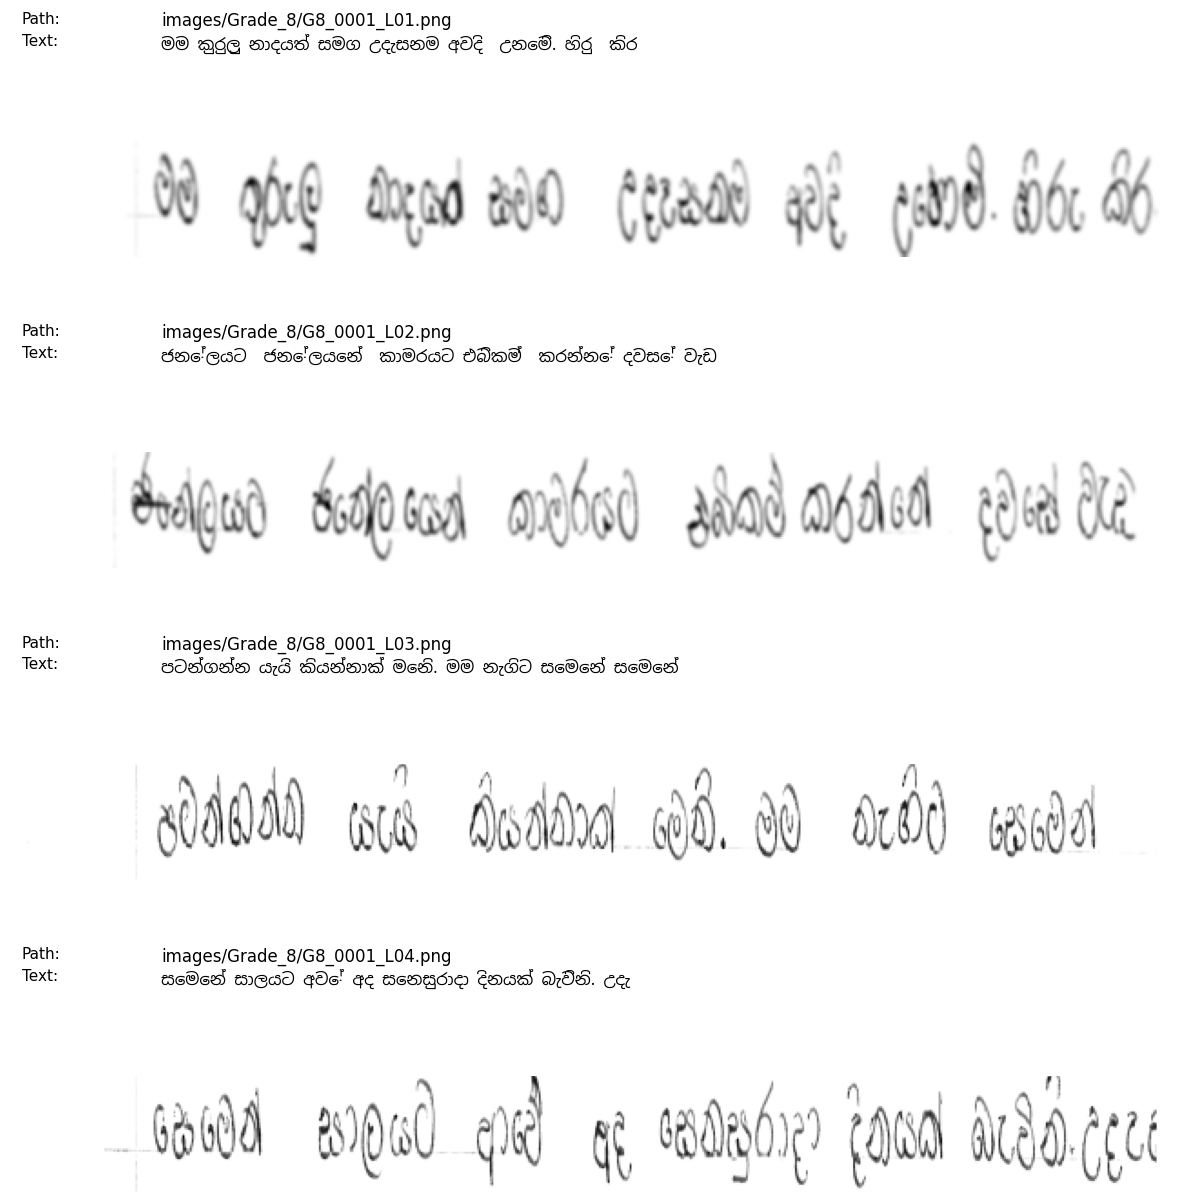

In [14]:
def show_samples(dataset, n=4):
    n = min(n, len(dataset))
    fig = plt.figure(figsize=(15, 3.9*n))
    gs = fig.add_gridspec(
        n * 2, 1,
        height_ratios=sum(([0.95, 2.2] for _ in range(n)), []),
        hspace=0.42,
    )

    for i in range(n):
        x, y, text, path = dataset[i]

        meta_ax = fig.add_subplot(gs[2*i, 0])
        draw_text_block(meta_ax, path_text=path, sample_text=text)

        img_ax = fig.add_subplot(gs[2*i + 1, 0])
        img_ax.imshow(x.squeeze(0).numpy(), cmap="gray")
        img_ax.axis("off")

    plt.show()

show_samples(train_ds, n=4)



## 13. DenseNet121-CRNN model
This keeps the strongest idea from your earlier notebook, but makes the implementation cleaner and more robust.

In [15]:
class DenseNetCRNN(nn.Module):
    def __init__(self, num_classes, img_h=64, img_w=512, pretrained=True):
        super().__init__()

        if pretrained:
            try:
                weights = models.DenseNet121_Weights.DEFAULT
                backbone = models.densenet121(weights=weights)
            except Exception:
                backbone = models.densenet121(pretrained=True)
        else:
            backbone = models.densenet121(weights=None)

        # Replace RGB input with grayscale while preserving pretrained information
        old_conv = backbone.features.conv0
        new_conv = nn.Conv2d(
            1,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features.conv0 = new_conv

        # Preserve width (time dimension) more aggressively
        backbone.features.transition1.pool = nn.AvgPool2d(kernel_size=2, stride=(2, 1))
        backbone.features.transition2.pool = nn.AvgPool2d(kernel_size=2, stride=(2, 1))
        backbone.features.transition3.pool = nn.AvgPool2d(kernel_size=2, stride=(2, 1))

        self.features = backbone.features

        # Infer feature dimension automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_h, img_w)
            feat = F.relu(self.features(dummy), inplace=False)
            _, c, h, w = feat.shape
            feature_dim = c * h
            self.time_steps = w

        self.rnn = nn.LSTM(
            input_size=feature_dim,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3,
        )
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        feat = F.relu(self.features(x), inplace=False)
        b, c, h, w = feat.shape
        feat = feat.permute(0, 3, 1, 2).contiguous().view(b, w, c * h)
        seq, _ = self.rnn(feat)
        seq = self.dropout(seq)
        logits = self.fc(seq)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DenseNetCRNN(
    num_classes=len(charset),
    img_h=IMG_HEIGHT,
    img_w=IMG_WIDTH,
    pretrained=USE_PRETRAINED,
).to(device)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

print(model.__class__.__name__)
print("Device:", device)
print("Output time steps:", model.time_steps)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 156MB/s]


DenseNetCRNN
Device: cuda
Output time steps: 157


## 14. Decoding and metrics
CER is your main metric. WER is the secondary metric for the thesis.

In [16]:
def greedy_decode(logits, idx2char):
    pred = logits.argmax(dim=-1).detach().cpu().numpy()
    results = []

    for seq in pred:
        last = None
        out = []
        for p in seq:
            if p != last and p != 0:
                out.append(idx2char[int(p)])
            last = p
        results.append("".join(out))
    return results

def _logsumexp2(a, b):
    if a == -np.inf:
        return b
    if b == -np.inf:
        return a
    m = max(a, b)
    return m + math.log(math.exp(a - m) + math.exp(b - m))

def ctc_prefix_beam_search_single(log_probs: np.ndarray, idx2char, beam_width=10, blank=0):
    beams = {(): (0.0, -np.inf)}  # prefix -> (p_blank, p_nonblank)

    for t in range(log_probs.shape[0]):
        next_beams = {}
        for prefix, (p_b, p_nb) in beams.items():
            for c in range(log_probs.shape[1]):
                p = float(log_probs[t, c])

                if c == blank:
                    n_p_b, n_p_nb = next_beams.get(prefix, (-np.inf, -np.inf))
                    n_p_b = _logsumexp2(n_p_b, _logsumexp2(p_b + p, p_nb + p))
                    next_beams[prefix] = (n_p_b, n_p_nb)
                    continue

                end = prefix[-1] if prefix else None
                new_prefix = prefix + (c,)

                if c == end:
                    n_p_b, n_p_nb = next_beams.get(new_prefix, (-np.inf, -np.inf))
                    n_p_nb = _logsumexp2(n_p_nb, p_b + p)
                    next_beams[new_prefix] = (n_p_b, n_p_nb)

                    n_p_b, n_p_nb = next_beams.get(prefix, (-np.inf, -np.inf))
                    n_p_nb = _logsumexp2(n_p_nb, p_nb + p)
                    next_beams[prefix] = (n_p_b, n_p_nb)
                else:
                    n_p_b, n_p_nb = next_beams.get(new_prefix, (-np.inf, -np.inf))
                    n_p_nb = _logsumexp2(n_p_nb, _logsumexp2(p_b + p, p_nb + p))
                    next_beams[new_prefix] = (n_p_b, n_p_nb)

        beams = dict(
            sorted(
                next_beams.items(),
                key=lambda x: _logsumexp2(x[1][0], x[1][1]),
                reverse=True,
            )[:beam_width]
        )

    best_prefix = max(beams.items(), key=lambda x: _logsumexp2(x[1][0], x[1][1]))[0]
    return "".join(idx2char[i] for i in best_prefix)

def decode_batch(logits, idx2char, decoder="greedy", beam_width=10):
    if decoder == "greedy":
        return greedy_decode(logits, idx2char)

    log_probs = F.log_softmax(logits, dim=-1).detach().cpu().numpy()
    return [
        ctc_prefix_beam_search_single(lp, idx2char, beam_width=beam_width, blank=0)
        for lp in log_probs
    ]

def edit_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    dp[:, 0] = np.arange(n + 1)
    dp[0, :] = np.arange(m + 1)

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,
                dp[i, j - 1] + 1,
                dp[i - 1, j - 1] + cost,
            )
    return int(dp[n, m])

def cer(ref, hyp):
    ref_chars = list(str(ref))
    hyp_chars = list(str(hyp))
    return edit_distance(ref_chars, hyp_chars) / max(1, len(ref_chars))

def wer(ref, hyp):
    ref_words = str(ref).split()
    hyp_words = str(hyp).split()
    return edit_distance(ref_words, hyp_words) / max(1, len(ref_words))


## 15. Validation helper

In [17]:
@torch.no_grad()
def evaluate_loader(model, loader, device, idx2char, max_batches=None, decoder="greedy", beam_width=10):
    model.eval()
    total_cer = []
    total_wer = []
    examples = []

    for batch_idx, (xs, _, _, texts, paths) in enumerate(loader):
        xs = xs.to(device, non_blocking=True)

        if USE_AMP:
            with torch.amp.autocast(device_type="cuda", enabled=True):
                logits = model(xs)
        else:
            logits = model(xs)

        preds = decode_batch(logits, idx2char, decoder=decoder, beam_width=beam_width)

        for gt, pred, path in zip(texts, preds, paths):
            total_cer.append(cer(gt, pred))
            total_wer.append(wer(gt, pred))
            if len(examples) < 12:
                examples.append((path, gt, pred))

        if max_batches is not None and (batch_idx + 1) >= max_batches:
            break

    return {
        "cer": float(np.mean(total_cer)) if total_cer else 1.0,
        "wer": float(np.mean(total_wer)) if total_wer else 1.0,
        "examples": examples,
    }


## 16. Training loop with early stopping and best-checkpoint saving

In [18]:
if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
else:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

best_val_cer = float("inf")
best_epoch = -1
history = []
patience_counter = 0

checkpoint_path = OUTPUT_DIR / "best_densenet121_writer_independent.pth"

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for xs, ys_cat, y_lens, texts, paths in pbar:
        xs = xs.to(device, non_blocking=True)
        ys_cat = ys_cat.to(device, non_blocking=True)
        y_lens = y_lens.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast(device_type="cuda", enabled=True):
                logits = model(xs)
                log_probs = F.log_softmax(logits, dim=-1)
                B, T, C = log_probs.shape
                input_lens = torch.full((B,), T, dtype=torch.long, device=device)

                loss = ctc_loss(
                    log_probs.permute(1, 0, 2),
                    ys_cat,
                    input_lens,
                    y_lens,
                )
        else:
            logits = model(xs)
            log_probs = F.log_softmax(logits, dim=-1)
            B, T, C = log_probs.shape
            input_lens = torch.full((B,), T, dtype=torch.long, device=device)
            loss = ctc_loss(
                log_probs.permute(1, 0, 2),
                ys_cat,
                input_lens,
                y_lens,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / max(1, len(train_loader))

    val_metrics = evaluate_loader(
        model,
        val_loader,
        device,
        idx2char,
        max_batches=None,
        decoder="greedy",
        beam_width=BEAM_WIDTH,
    )
    val_cer_score = val_metrics["cer"]
    val_wer_score = val_metrics["wer"]

    scheduler.step(val_cer_score)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_cer": val_cer_score,
        "val_wer": val_wer_score,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_CER={val_cer_score:.4f} | "
        f"val_WER={val_wer_score:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_cer_score < best_val_cer:
        best_val_cer = val_cer_score
        best_epoch = epoch
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_cer": best_val_cer,
                "charset": charset,
                "config": {
                    "IMG_HEIGHT": IMG_HEIGHT,
                    "IMG_WIDTH": IMG_WIDTH,
                    "BATCH_SIZE": BATCH_SIZE,
                    "LR": LR,
                    "WEIGHT_DECAY": WEIGHT_DECAY,
                    "EPOCHS": EPOCHS,
                    "SEED": SEED,
                    "USE_TRAIN_AUGMENT": USE_TRAIN_AUGMENT,
                    "FINAL_DECODER": FINAL_DECODER,
                    "BEAM_WIDTH": BEAM_WIDTH,
                },
            },
            checkpoint_path,
        )
        print(f"Saved new best checkpoint -> {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
history_df.to_json(OUTPUT_DIR / "training_history.json", orient="records", force_ascii=False, indent=2)

run_config = {
    "IMG_HEIGHT": IMG_HEIGHT,
    "IMG_WIDTH": IMG_WIDTH,
    "BATCH_SIZE": BATCH_SIZE,
    "TRAIN_RATIO": TRAIN_RATIO,
    "VAL_RATIO": VAL_RATIO,
    "TEST_RATIO": TEST_RATIO,
    "EPOCHS": EPOCHS,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "PATIENCE": PATIENCE,
    "SEED": SEED,
    "FINAL_DECODER": FINAL_DECODER,
    "BEAM_WIDTH": BEAM_WIDTH,
    "USE_TRAIN_AUGMENT": USE_TRAIN_AUGMENT,
    "NORMALIZE_TO_MINUS1_1": NORMALIZE_TO_MINUS1_1,
}
with open(OUTPUT_DIR / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

print("Saved training_history.csv, training_history.json, and run_config.json")
history_df.tail()


Epoch 1/40:   0%|          | 0/368 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: ctc_loss_backward_gpu does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01 | train_loss=3.5417 | val_CER=0.8228 | val_WER=0.9990 | lr=1.00e-04
Saved new best checkpoint -> /content/outputs_writer_independent_densenet121/best_densenet121_writer_independent.pth


Epoch 2/40:   0%|          | 0/368 [00:00<?, ?it/s]

Epoch 02 | train_loss=1.3167 | val_CER=0.1818 | val_WER=0.5474 | lr=1.00e-04
Saved new best checkpoint -> /content/outputs_writer_independent_densenet121/best_densenet121_writer_independent.pth


...

Epoch 30/40:   0%|          | 0/368 [00:00<?, ?it/s]

Epoch 30 | train_loss=0.0267 | val_CER=0.0671 | val_WER=0.2070 | lr=6.25e-06
No improvement. Patience: 7/8


Epoch 31/40:   0%|          | 0/368 [00:00<?, ?it/s]

Epoch 31 | train_loss=0.0251 | val_CER=0.0675 | val_WER=0.2097 | lr=6.25e-06
No improvement. Patience: 8/8
Early stopping triggered.
Saved training_history.csv, training_history.json, and run_config.json


,epoch,train_loss,val_cer,val_wer,lr
26,27,0.032847,0.068397,0.213892,0.000013
27,28,0.029400,0.067463,0.207554,0.000013
28,29,0.028713,0.067630,0.207426,0.000006
29,30,0.026733,0.067064,0.207001,0.000006
30,31,0.025118,0.067514,0.209685,0.000006


## 17. Plot training history

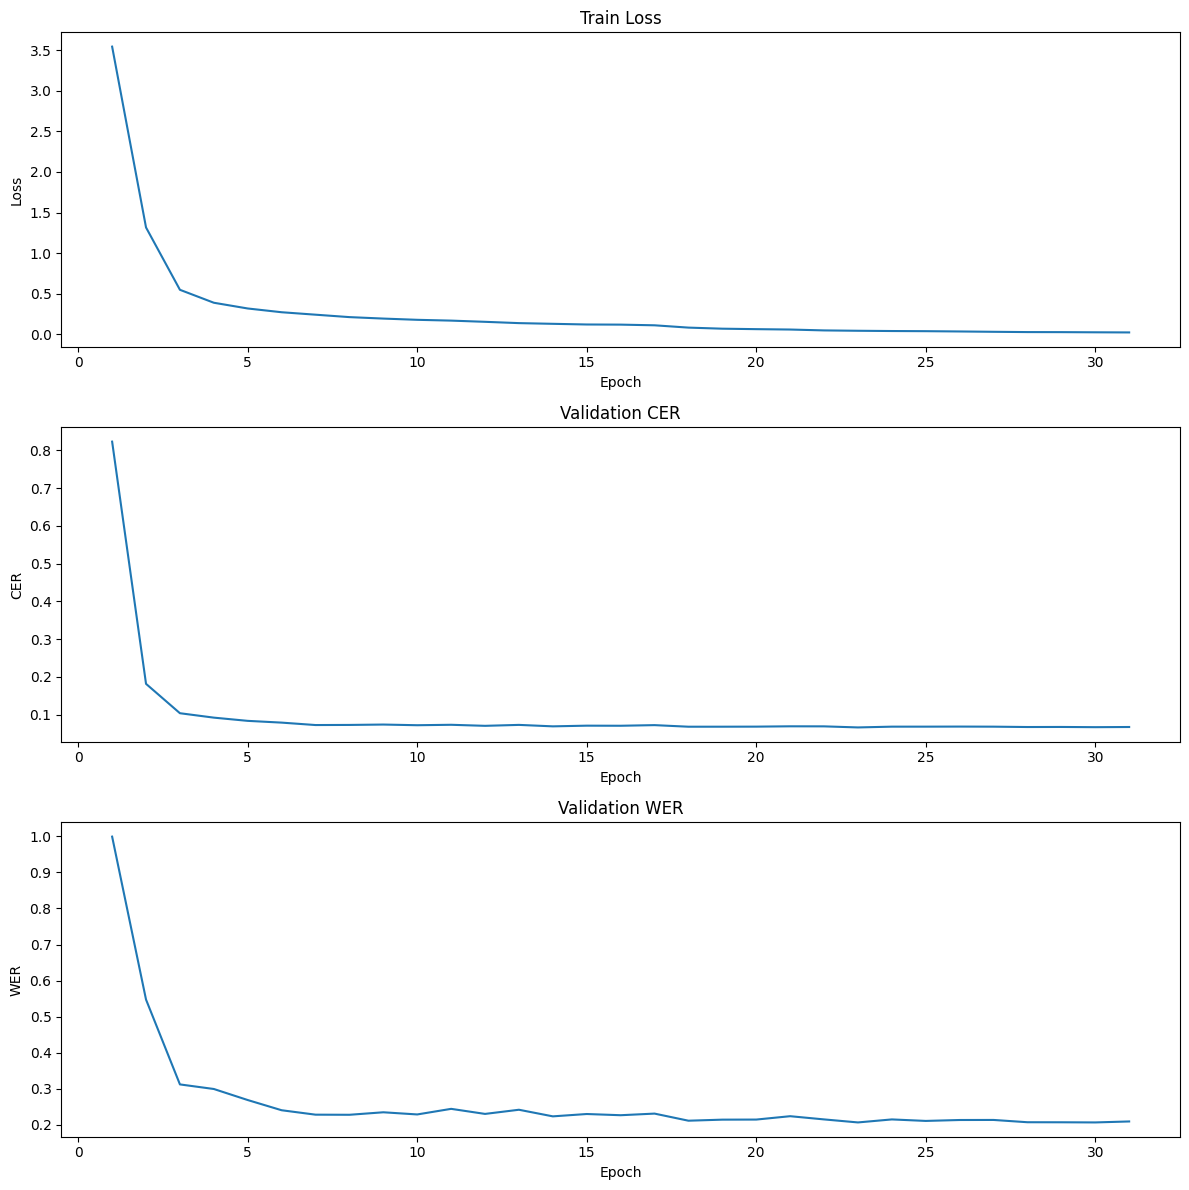

Best epoch: 23
Best validation CER: 0.06638493079872272
Saved training curve image: /content/outputs_writer_independent_densenet121/training_curves.png


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(history_df["epoch"], history_df["train_loss"])
axes[0].set_title("Train Loss", fontfamily="DejaVu Sans")
axes[0].set_xlabel("Epoch", fontfamily="DejaVu Sans")
axes[0].set_ylabel("Loss", fontfamily="DejaVu Sans")

axes[1].plot(history_df["epoch"], history_df["val_cer"])
axes[1].set_title("Validation CER", fontfamily="DejaVu Sans")
axes[1].set_xlabel("Epoch", fontfamily="DejaVu Sans")
axes[1].set_ylabel("CER", fontfamily="DejaVu Sans")

axes[2].plot(history_df["epoch"], history_df["val_wer"])
axes[2].set_title("Validation WER", fontfamily="DejaVu Sans")
axes[2].set_xlabel("Epoch", fontfamily="DejaVu Sans")
axes[2].set_ylabel("WER", fontfamily="DejaVu Sans")

plt.tight_layout()

training_curve_path = OUTPUT_DIR / "training_curves.png"
fig.savefig(training_curve_path, dpi=220, bbox_inches="tight")
plt.show()

best_summary = {
    "best_epoch": int(best_epoch),
    "best_validation_cer": float(best_val_cer),
    "training_curve_file": training_curve_path.name,
}
with open(OUTPUT_DIR / "best_checkpoint_summary.json", "w", encoding="utf-8") as f:
    json.dump(best_summary, f, ensure_ascii=False, indent=2)

print("Best epoch:", best_epoch)
print("Best validation CER:", best_val_cer)
print("Saved training curve image:", training_curve_path)


## 18. Load best checkpoint

In [20]:
ckpt = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Best validation CER:", ckpt["best_val_cer"])

Loaded best checkpoint from epoch: 23
Best validation CER: 0.06638493079872272


## 19. Final evaluation on validation and test sets
These are the numbers you should report in the thesis.

Running final evaluation with decoder: beam | beam width: 10


,split,CER,WER
0,validation,0.066371,0.207317
1,test,0.086424,0.251619


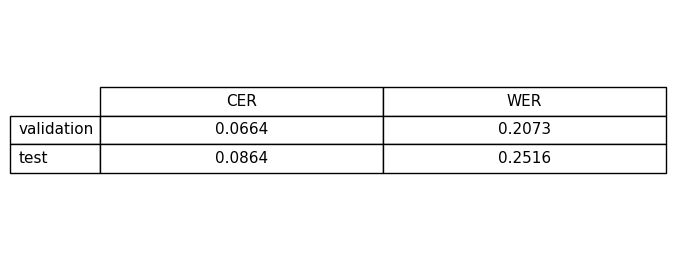

Saved final_results.csv, final_results.json, validation_examples.csv, test_examples.csv
Saved final metrics figure: /content/outputs_writer_independent_densenet121/final_metrics_table.png


In [21]:
print("Running final evaluation with decoder:", FINAL_DECODER, "| beam width:", BEAM_WIDTH)

val_final = evaluate_loader(
    model,
    val_loader,
    device,
    idx2char,
    max_batches=None,
    decoder=FINAL_DECODER,
    beam_width=BEAM_WIDTH,
)
test_final = evaluate_loader(
    model,
    test_loader,
    device,
    idx2char,
    max_batches=None,
    decoder=FINAL_DECODER,
    beam_width=BEAM_WIDTH,
)

final_df = pd.DataFrame([
    {"split": "validation", "CER": val_final["cer"], "WER": val_final["wer"]},
    {"split": "test",       "CER": test_final["cer"], "WER": test_final["wer"]},
])
display(final_df)
final_df.to_csv(OUTPUT_DIR / "final_results.csv", index=False)
final_df.to_json(OUTPUT_DIR / "final_results.json", orient="records", indent=2)

# Save a few qualitative prediction examples for later thesis discussion
val_examples_df = pd.DataFrame(val_final["examples"], columns=["image_path", "ground_truth", "prediction"])
test_examples_df = pd.DataFrame(test_final["examples"], columns=["image_path", "ground_truth", "prediction"])
val_examples_df.to_csv(OUTPUT_DIR / "validation_examples.csv", index=False)
test_examples_df.to_csv(OUTPUT_DIR / "test_examples.csv", index=False)

# Save a clean metrics figure so you do not need manual screenshots
fig, ax = plt.subplots(figsize=(7, 1.8 + 0.45 * len(final_df)))
ax.axis("off")
tbl = ax.table(
    cellText=np.round(final_df[["CER", "WER"]].values, 4),
    rowLabels=final_df["split"].tolist(),
    colLabels=["CER", "WER"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.5)
plt.tight_layout()

metrics_table_path = OUTPUT_DIR / "final_metrics_table.png"
fig.savefig(metrics_table_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved final_results.csv, final_results.json, validation_examples.csv, test_examples.csv")
print("Saved final metrics figure:", metrics_table_path)


## 20. Show sample predictions
Use these screenshots in your thesis or viva.

Validation examples


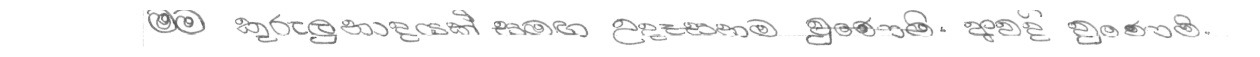

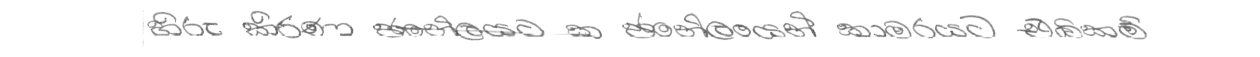

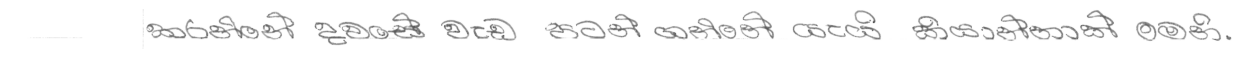

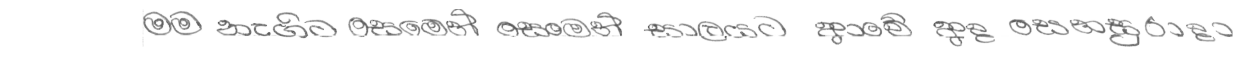

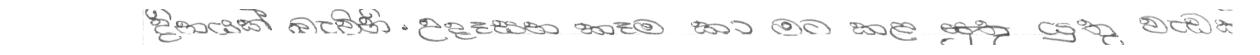

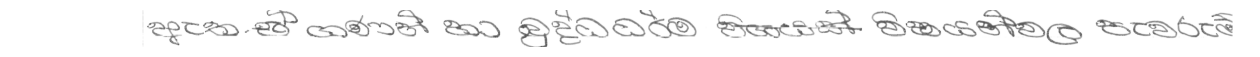

Verification view (repr shows exact raw strings):

[1] images/Grade_8/G8_0004_L01.png
GT   repr: 'මම කුරුලුනාදයක් සමග උදැසනම වුණෙමි අවදි  වුණෙමි.'
Pred repr: 'මම කුරුලු නාදයත් සමග උදැසනම වුණෙමි. අවදි  වුණෙමි.'
Exact match: False

[2] images/Grade_8/G8_0004_L02.png
GT   repr: 'හිරු  කිරණ  ජනේලයට ක ජනේලයෙන්  කාමරයට එබිකම්'
Pred repr: 'හිරු  කිරණ  ජනේලයව   ජනේලයෙන්  කාමරයට එබිකම්'
Exact match: False

[3] images/Grade_8/G8_0004_L03.png
GT   repr: 'කරන්නේ දවසේ වැඩ පටන් ගන්න යැයි කියන්නාක් මෙනි.'
Pred repr: 'කරන්නේ දවසේ වැඩ පටන් ගන්න් යැයි කියන්නාක් මෙනි.'
Exact match: False
Test examples


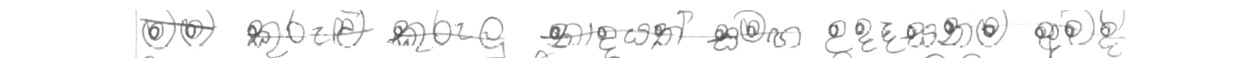

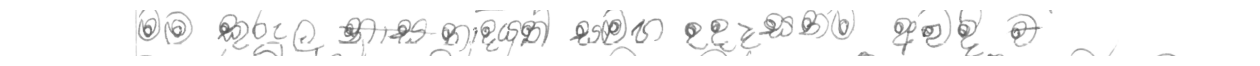

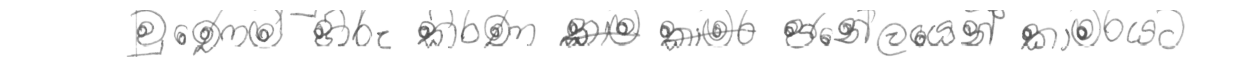

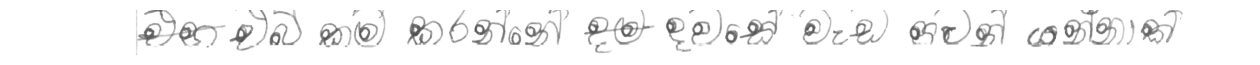

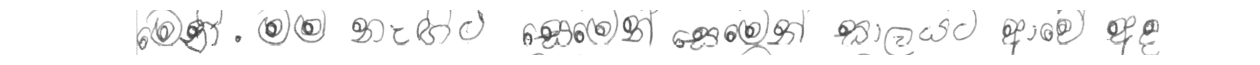

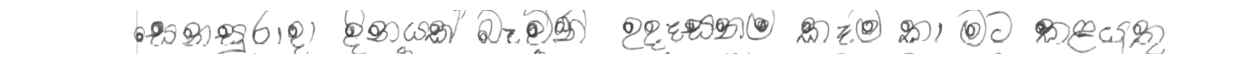

Verification view (repr shows exact raw strings):

[1] images/Grade_6/G6_0077_L01.png
GT   repr: 'මම කුරුළු කුරුලු නාදයත් සමග උදැසනම අවදි'
Pred repr: 'මම කුරුළු කුරුලු නරදයක් සමඟ උදැසනම අවදි'
Exact match: False

[2] images/Grade_6/G6_0077_L02.png
GT   repr: 'මම කුරුලු නාස නාදයත් සමග උදැසනම අවදි  ව'
Pred repr: 'මම කුරුලු නු නාදයති සමග උදෘඩානිම අවදි'
Exact match: False

[3] images/Grade_6/G6_0077_L03.png
GT   repr: 'වුණෙමි  හිරු  කිරණ කාම කාමර ජනේලයෙන්  කාමරයට'
Pred repr: 'වුණෙම් හිරු  කිරණ ක කෑම ජනේලයෙන්  කාමරයට'
Exact match: False


In [22]:

from IPython.display import HTML, display
from html import escape

def _display_prediction_metadata(rel_path, gt, pred):
    match_text = "Exact match" if gt == pred else "Different strings"
    match_color = "#166534" if gt == pred else "#b91c1c"

    html_block = f"""
    <div style="
        border:1px solid #e5e7eb;
        border-radius:10px;
        padding:12px 14px;
        margin:10px 0 8px 0;
        background:#ffffff;
        line-height:1.55;
    ">
      <div style="margin-bottom:6px;">
        <span style="font-weight:700; color:#111827;">Path:</span>
        <span style="font-family:monospace; color:#374151;">{escape(str(rel_path))}</span>
      </div>
      <div style="margin-bottom:6px;">
        <span style="font-weight:700; color:#111827;">GT (label):</span>
        <span style="font-size:18px; color:#111827;">{escape(str(gt))}</span>
      </div>
      <div style="margin-bottom:6px;">
        <span style="font-weight:700; color:#111827;">Pred (model):</span>
        <span style="font-size:18px; color:#111827;">{escape(str(pred))}</span>
      </div>
      <div>
        <span style="font-weight:700; color:#111827;">Match:</span>
        <span style="font-weight:700; color:{match_color};">{match_text}</span>
      </div>
    </div>
    """
    display(HTML(html_block))


def show_predictions(examples, n=8):
    """
    Display predictions without drawing Sinhala text inside matplotlib.
    This is a visualization-only fix: it does NOT change the dataset,
    model, decoding, CER/WER, or any research result.
    """
    n = min(n, len(examples))
    chosen = examples[:n]

    for i, (rel_path, gt, pred) in enumerate(chosen, 1):
        _display_prediction_metadata(rel_path, gt, pred)

        img = cv2.imread(str(DATA_ROOT / rel_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Could not read image: {DATA_ROOT / rel_path}")
            continue

        plt.figure(figsize=(16, 2.8))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.show()


def verify_prediction_examples(examples, n=5):
    print("Verification view (repr shows exact raw strings):")
    for i, (rel_path, gt, pred) in enumerate(examples[:min(n, len(examples))], 1):
        print(f"\n[{i}] {rel_path}")
        print("GT   repr:", repr(gt))
        print("Pred repr:", repr(pred))
        print("Exact match:", gt == pred)


print('Validation examples')
show_predictions(val_final['examples'], n=6)
verify_prediction_examples(val_final['examples'], n=3)

print('Test examples')
show_predictions(test_final['examples'], n=6)
verify_prediction_examples(test_final['examples'], n=3)


## 21. Export a thesis-ready summary
This cell prints a short summary you can paste into your report.

In [23]:
num_train_writers = train_df["writer_id"].nunique()
num_val_writers = val_df["writer_id"].nunique()
num_test_writers = test_df["writer_id"].nunique()

print("=" * 70)
print("FINAL THESIS SUMMARY")
print("=" * 70)
print(f"Total line images        : {len(df)}")
print(f"Unique writers/pages     : {df['writer_id'].nunique()}")
print(f"Train samples            : {len(train_df)}  | writers/pages: {num_train_writers}")
print(f"Validation samples       : {len(val_df)}  | writers/pages: {num_val_writers}")
print(f"Test samples             : {len(test_df)}  | writers/pages: {num_test_writers}")
print(f"Best epoch               : {best_epoch}")
print(f"Validation CER           : {val_final['cer']:.4f}")
print(f"Validation WER           : {val_final['wer']:.4f}")
print(f"Test CER                 : {test_final['cer']:.4f}")
print(f"Test WER                 : {test_final['wer']:.4f}")
print("Model                    : DenseNet121-CRNN")
print("Evaluation protocol      : Writer-independent grouped split")
print("=" * 70)

FINAL THESIS SUMMARY
Total line images        : 5482
Unique writers/pages     : 345
Train samples            : 4411  | writers/pages: 276
Validation samples       : 555  | writers/pages: 34
Test samples             : 516  | writers/pages: 35
Best epoch               : 23
Validation CER           : 0.0664
Validation WER           : 0.2073
Test CER                 : 0.0864
Test WER                 : 0.2516
Model                    : DenseNet121-CRNN
Evaluation protocol      : Writer-independent grouped split


## 22. Optional: single-image inference
Use this to test one image manually.

In [24]:
def predict_one_image(image_path, model, idx2char, img_h=64, img_w=512):
    model.eval()
    image_path = Path(image_path)

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)

    h, w = img.shape
    new_h = img_h
    new_w = max(1, int(w * (new_h / h)))
    new_w = min(new_w, img_w)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.ones((img_h, img_w), dtype=np.uint8) * 255
    canvas[:, :new_w] = img

    x = torch.tensor(canvas, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    x = x.to(device)

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=USE_AMP):
        logits = model(x)
    pred = decode_batch(logits, idx2char, decoder=FINAL_DECODER, beam_width=BEAM_WIDTH)[0]

    fig = plt.figure(figsize=(14, 4.6))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.05, 2.2], hspace=0.35)

    meta_ax = fig.add_subplot(gs[0, 0])
    draw_text_block(meta_ax, path_text=image_path.name, pred_text=pred)

    img_ax = fig.add_subplot(gs[1, 0])
    img_ax.imshow(canvas, cmap='gray')
    img_ax.axis('off')

    plt.show()
    return pred

# Example:
# predict_one_image('/content/final_dataset/some_line.png', model, idx2char)



## 23. Export / download the trained model safely
This section **does not change your research pipeline or results**. It only packages the final artifacts so you can keep the trained model on your PC or in Google Drive.

It exports:
- `best_densenet121_writer_independent.pth` (best trained PyTorch checkpoint)
- `charset.json` (character mapping)
- `training_history.csv`
- `final_results.csv`
- a ready-to-download zip package


In [25]:
from pathlib import Path
import shutil
import json
from datetime import datetime

# -------- paths --------
OUTPUT_DIR = Path(OUTPUT_DIR)
EXPORT_DIR = Path("/content/sinhala_htr_export_package")
ZIP_BASE = "/content/sinhala_htr_export_package"

required_files = [
    OUTPUT_DIR / "best_densenet121_writer_independent.pth",
    OUTPUT_DIR / "charset.json",
    OUTPUT_DIR / "training_history.csv",
    OUTPUT_DIR / "final_results.csv",
]

optional_files = [
    OUTPUT_DIR / "train_split.csv",
    OUTPUT_DIR / "val_split.csv",
    OUTPUT_DIR / "test_split.csv",
    OUTPUT_DIR / "split_summary.csv",
    OUTPUT_DIR / "writer_split.json",
    OUTPUT_DIR / "training_history.json",
    OUTPUT_DIR / "run_config.json",
    OUTPUT_DIR / "training_curves.png",
    OUTPUT_DIR / "best_checkpoint_summary.json",
    OUTPUT_DIR / "final_results.json",
    OUTPUT_DIR / "validation_examples.csv",
    OUTPUT_DIR / "test_examples.csv",
    OUTPUT_DIR / "final_metrics_table.png",
]

# -------- safety checks --------
for path in required_files:
    print(f"Required exists: {path.exists()} | {path}")
    assert path.exists(), f"Required export file missing: {path}"

# -------- build export package folder --------
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

copied_files = []

for path in required_files + [p for p in optional_files if p.exists()]:
    shutil.copy2(path, EXPORT_DIR / path.name)
    copied_files.append(path.name)

# Save a small readme so future-you knows what is inside
readme_text = f"""Sinhala HTR export package

This package was created automatically by the notebook.
It does NOT retrain the model or change the experiment.
It only collects the final research artifacts into one folder/zip.

Core files:
- best_densenet121_writer_independent.pth : best trained PyTorch checkpoint
- charset.json : character set used for CTC decoding
- training_history.csv : epoch-by-epoch training history
- final_results.csv : final validation/test CER and WER

Additional exported evidence may include:
- split CSV files and writer_split.json
- split_summary.csv
- training_history.json
- run_config.json
- training_curves.png
- final_results.json
- validation_examples.csv / test_examples.csv
- final_metrics_table.png

Important preprocessing settings:
- IMG_HEIGHT = {IMG_HEIGHT}
- IMG_WIDTH = {IMG_WIDTH}
- NORMALIZE_TO_MINUS1_1 = {NORMALIZE_TO_MINUS1_1}
- FINAL_DECODER = {FINAL_DECODER}
- BEAM_WIDTH = {BEAM_WIDTH}
"""
(EXPORT_DIR / "README.txt").write_text(readme_text, encoding="utf-8")

export_manifest = {
    "created_utc": datetime.utcnow().isoformat() + "Z",
    "output_dir": str(OUTPUT_DIR),
    "export_dir": str(EXPORT_DIR),
    "copied_files": copied_files,
    "required_files": [p.name for p in required_files],
    "optional_files_included": [p.name for p in optional_files if p.exists()],
}
(EXPORT_DIR / "export_manifest.json").write_text(
    json.dumps(export_manifest, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# -------- make downloadable zip --------
zip_path = shutil.make_archive(ZIP_BASE, "zip", root_dir=EXPORT_DIR)

print("\nExport folder created:", EXPORT_DIR)
print("Zip created:", zip_path)
print("Copied files:", copied_files)

# -------- optional copy to Drive --------
DRIVE_EXPORT_DIR = Path("/content/drive/MyDrive/SinhalaHTR_Export")
try:
    DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    for item in EXPORT_DIR.iterdir():
        shutil.copy2(item, DRIVE_EXPORT_DIR / item.name)
    shutil.copy2(zip_path, DRIVE_EXPORT_DIR / Path(zip_path).name)
    print("Copied export package to Drive:", DRIVE_EXPORT_DIR)
except Exception as e:
    print("Drive copy skipped or failed:", e)

# -------- direct download --------
try:
    from google.colab import files
    print("\nStarting zip download...")
    files.download(zip_path)
except Exception as e:
    print("Auto download skipped or failed:", e)


Required exists: True | /content/outputs_writer_independent_densenet121/best_densenet121_writer_independent.pth
Required exists: True | /content/outputs_writer_independent_densenet121/charset.json
Required exists: True | /content/outputs_writer_independent_densenet121/training_history.csv
Required exists: True | /content/outputs_writer_independent_densenet121/final_results.csv


/tmp/ipykernel_7539/1064882686.py:83: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.utcnow().isoformat() + "Z",



Export folder created: /content/sinhala_htr_export_package
Zip created: /content/sinhala_htr_export_package.zip
Copied files: ['best_densenet121_writer_independent.pth', 'charset.json', 'training_history.csv', 'final_results.csv', 'train_split.csv', 'val_split.csv', 'test_split.csv', 'split_summary.csv', 'writer_split.json', 'training_history.json', 'run_config.json', 'training_curves.png', 'best_checkpoint_summary.json', 'final_results.json', 'validation_examples.csv', 'test_examples.csv', 'final_metrics_table.png']
Copied export package to Drive: /content/drive/MyDrive/SinhalaHTR_Export

Starting zip download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Optional quick diagnostic
max_text_len = int(df["text"].str.len().max())
print("Max text length in dataset:", max_text_len)
print("Model output time steps   :", model.time_steps)
if max_text_len > model.time_steps:
    print("WARNING: Some labels are longer than the model time dimension. Consider increasing IMG_WIDTH.")
else:
    print("OK: model time dimension is long enough for the longest label.")


Max text length in dataset: 95
Model output time steps   : 157
OK: model time dimension is long enough for the longest label.


## 23A. Reproducibility note for thesis

Because deep learning training includes random initialization, shuffled mini-batches, augmentation, and GPU-level numeric variation, tiny run-to-run metric changes can happen even with the same writer-independent split. In this notebook, `STRICT_REPRODUCIBILITY=True` is enabled to reduce that variation as much as practical without changing the research design.


## 24. What to report in the thesis
In your report, mention these points clearly:

1. The final experiment used the **full segmented dataset**.
2. The evaluation was **writer-independent**, using grouped splits by writer/page ID.
3. DenseNet121-CRNN was selected as the final architecture.
4. The main metric was **CER**, with **WER** as the secondary metric.
5. Any earlier notebooks using random splits were **pilot experiments**, not the final evaluation.
- For the final thesis table, **report the test CER/WER** as the main held-out result.
- Validation CER/WER are for model selection.
- This tuned version may reduce errors slightly through wider input, mild augmentation, and beam-search decoding.
